## **Cálculo del Radio de Giro** 

In [1]:
from funciones import calcular_radio_giro_promedio
import os
import gsd.hoomd
import numpy as np

In [2]:
def mapear_orden_cadenas_por_enlaces(frame, num_cadenas, longitud_cadena):
    """
    Utiliza la matriz de bonds para reconstruir la lista de índices de partículas
    en el orden molecular exacto (de cabeza a cola para cada cadena).
    """
    enlaces = frame.bonds.group
    
    # Creamos un diccionario de adyacencia (lista de vecinos)
    adj = {}
    for u, v in enlaces:
        if u not in adj: adj[u] = []
        if v not in adj: adj[v] = []
        adj[u].append(v)
        adj[v].append(v) # Para búsquedas bidireccionales si fuera necesario

    mapa_indices_ordenados = []
    
    # Tus datos muestran que las cabezas de las cadenas inician del índice 0 al (num_cadenas - 1)
    for cabeza in range(num_cadenas):
        cadena_actual = [cabeza]
        nodo_actual = cabeza
        
        # Caminamos a lo largo de los enlaces para encontrar los g-1 miembros restantes
        for _ in range(longitud_cadena - 1):
            vecinos = adj.get(nodo_actual, [])
            # Buscamos el vecino que NO hayamos agregado ya a la cadena
            siguiente_nodo = [v for v in vecinos if v not in cadena_actual]
            if siguiente_nodo:
                nodo_actual = siguiente_nodo[0]
                cadena_actual.append(nodo_actual)
            else:
                break # Por seguridad si se corta la cadena
                
        mapa_indices_ordenados.extend(cadena_actual)
        
    return np.array(mapa_indices_ordenados)

In [11]:
# ###############     Ejecución del Script      #######################

grado_polimerizacion = [8]
frame_inicial = 300
ruta_archivo_base = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P14_Polimero_Solvente'
temperaturas = [0.60]
resultados = {}
epsilon = 0.25

for T in temperaturas:
    # Agregamos los resultados clasificados por temperaturas
    resultados[T] = {
        'Rg': [],
        'Rg_std': []
    }

    for g in grado_polimerizacion:
        archivo = f'Poly-Solv_T{T:.2f}_epsSP{epsilon:.2f}_monom_{g}.gsd'
        ruta_final = os.path.join(ruta_archivo_base, archivo)
        
        print(f'Analizando: {archivo}')
        
        try:
            with gsd.hoomd.open(name=ruta_final, mode='r') as trayectoria:
                num_frames = len(trayectoria)
                frames_analisis = num_frames - frame_inicial
                primer_frame = trayectoria[0]
                segundo_frame = trayectoria[1]
                print(f'Cada frame tiene {segundo_frame.configuration.step} pasos')
                
                tipos_particulas = primer_frame.particles.types
                num_particulas = primer_frame.particles.N
                id_polimero = tipos_particulas.index('P')

                filtro_polimero = (primer_frame.particles.typeid == id_polimero)
                num_monomeros = np.sum(filtro_polimero)
                num_cadenas = num_monomeros // g

                print(f'  -> Total frames: {num_frames}')
                print(f'  -> Frame inicial {frame_inicial}')
                print(f'  -> Frames a analizar: {frames_analisis}')
                print(f'  -> Total de partículas: {num_particulas}')
                print(f"  -> Monómeros de polímero: {num_monomeros}")
                print(f"  -> Cadenas independientes: {num_cadenas}")

                # --- NUEVA ETAPA: Construir el mapa de ordenamiento molecular ---
                print("  -> Reconstruyendo topología molecular desde los enlaces...")
                indices_ordenados_totales = mapear_orden_cadenas_por_enlaces(primer_frame, num_cadenas, g)

                trayectoria_polimero = np.empty((frames_analisis, num_monomeros, 3))
                # Revisamos la cantidad de cajas que hubo durante la simulación
                cajas_trayectoria = np.empty((frames_analisis, 3))

                for i, frame in enumerate(trayectoria[frame_inicial:]):
                    # Extraemos la caja de cada frame
                    cajas_trayectoria[i] = frame.configuration.box[:3]

                    posiciones_todas = frame.particles.position

                    # Filtramos los monómeros durante cada frame
                    filtro_dinamico = (frame.particles.typeid == id_polimero)
                    trayectoria_polimero[i] = posiciones_todas[indices_ordenados_totales]
                    

                # El cálculo se queda ADENTRO del bloque para asegurar que el archivo se leyó bien
                rg_promedio, std_rg, lista_rg = calcular_radio_giro_promedio(trayectoria_polimero, longitud_cadenas=g, dimensiones_caja=cajas_trayectoria)
                
                print(f"  -> Radio de Giro Promedio: {rg_promedio:.4f}")
                print(f"  -> Desviación estándar: {std_rg:.4f}\n")

                resultados[T]['Rg'].append(rg_promedio)
                resultados[T]['Rg_std'].append(std_rg)


        except FileNotFoundError:
            print(f'  [ERROR] No se encontró el archivo: {archivo}\n')
        except Exception as e:
            print(f'  [ERROR] Ocurrió un problema inesperado analizando {archivo}: {e}\n')
            # Importante: Esto te dirá el error real si algo falla adentro
            import traceback
            print(f'  [ERROR] Ocurrió un problema de ejecución:\n{traceback.format_exc()}\n')

Analizando: Poly-Solv_T0.60_epsSP0.25_monom_8.gsd
Cada frame tiene 5000 pasos
  -> Total frames: 325
  -> Frame inicial 300
  -> Frames a analizar: 25
  -> Total de partículas: 240000
  -> Monómeros de polímero: 2400
  -> Cadenas independientes: 300
  -> Reconstruyendo topología molecular desde los enlaces...
  -> Radio de Giro Promedio: 0.9737
  -> Desviación estándar: 0.1688



In [7]:
# Agregado de resultados 
print(resultados)

{0.6: {'Rg': [np.float64(0.9737461691730671)], 'Rg_std': [np.float64(0.16876120756113108)]}}


TypeError: Improper input: func input vector length N=2 must not exceed func output vector length M=1

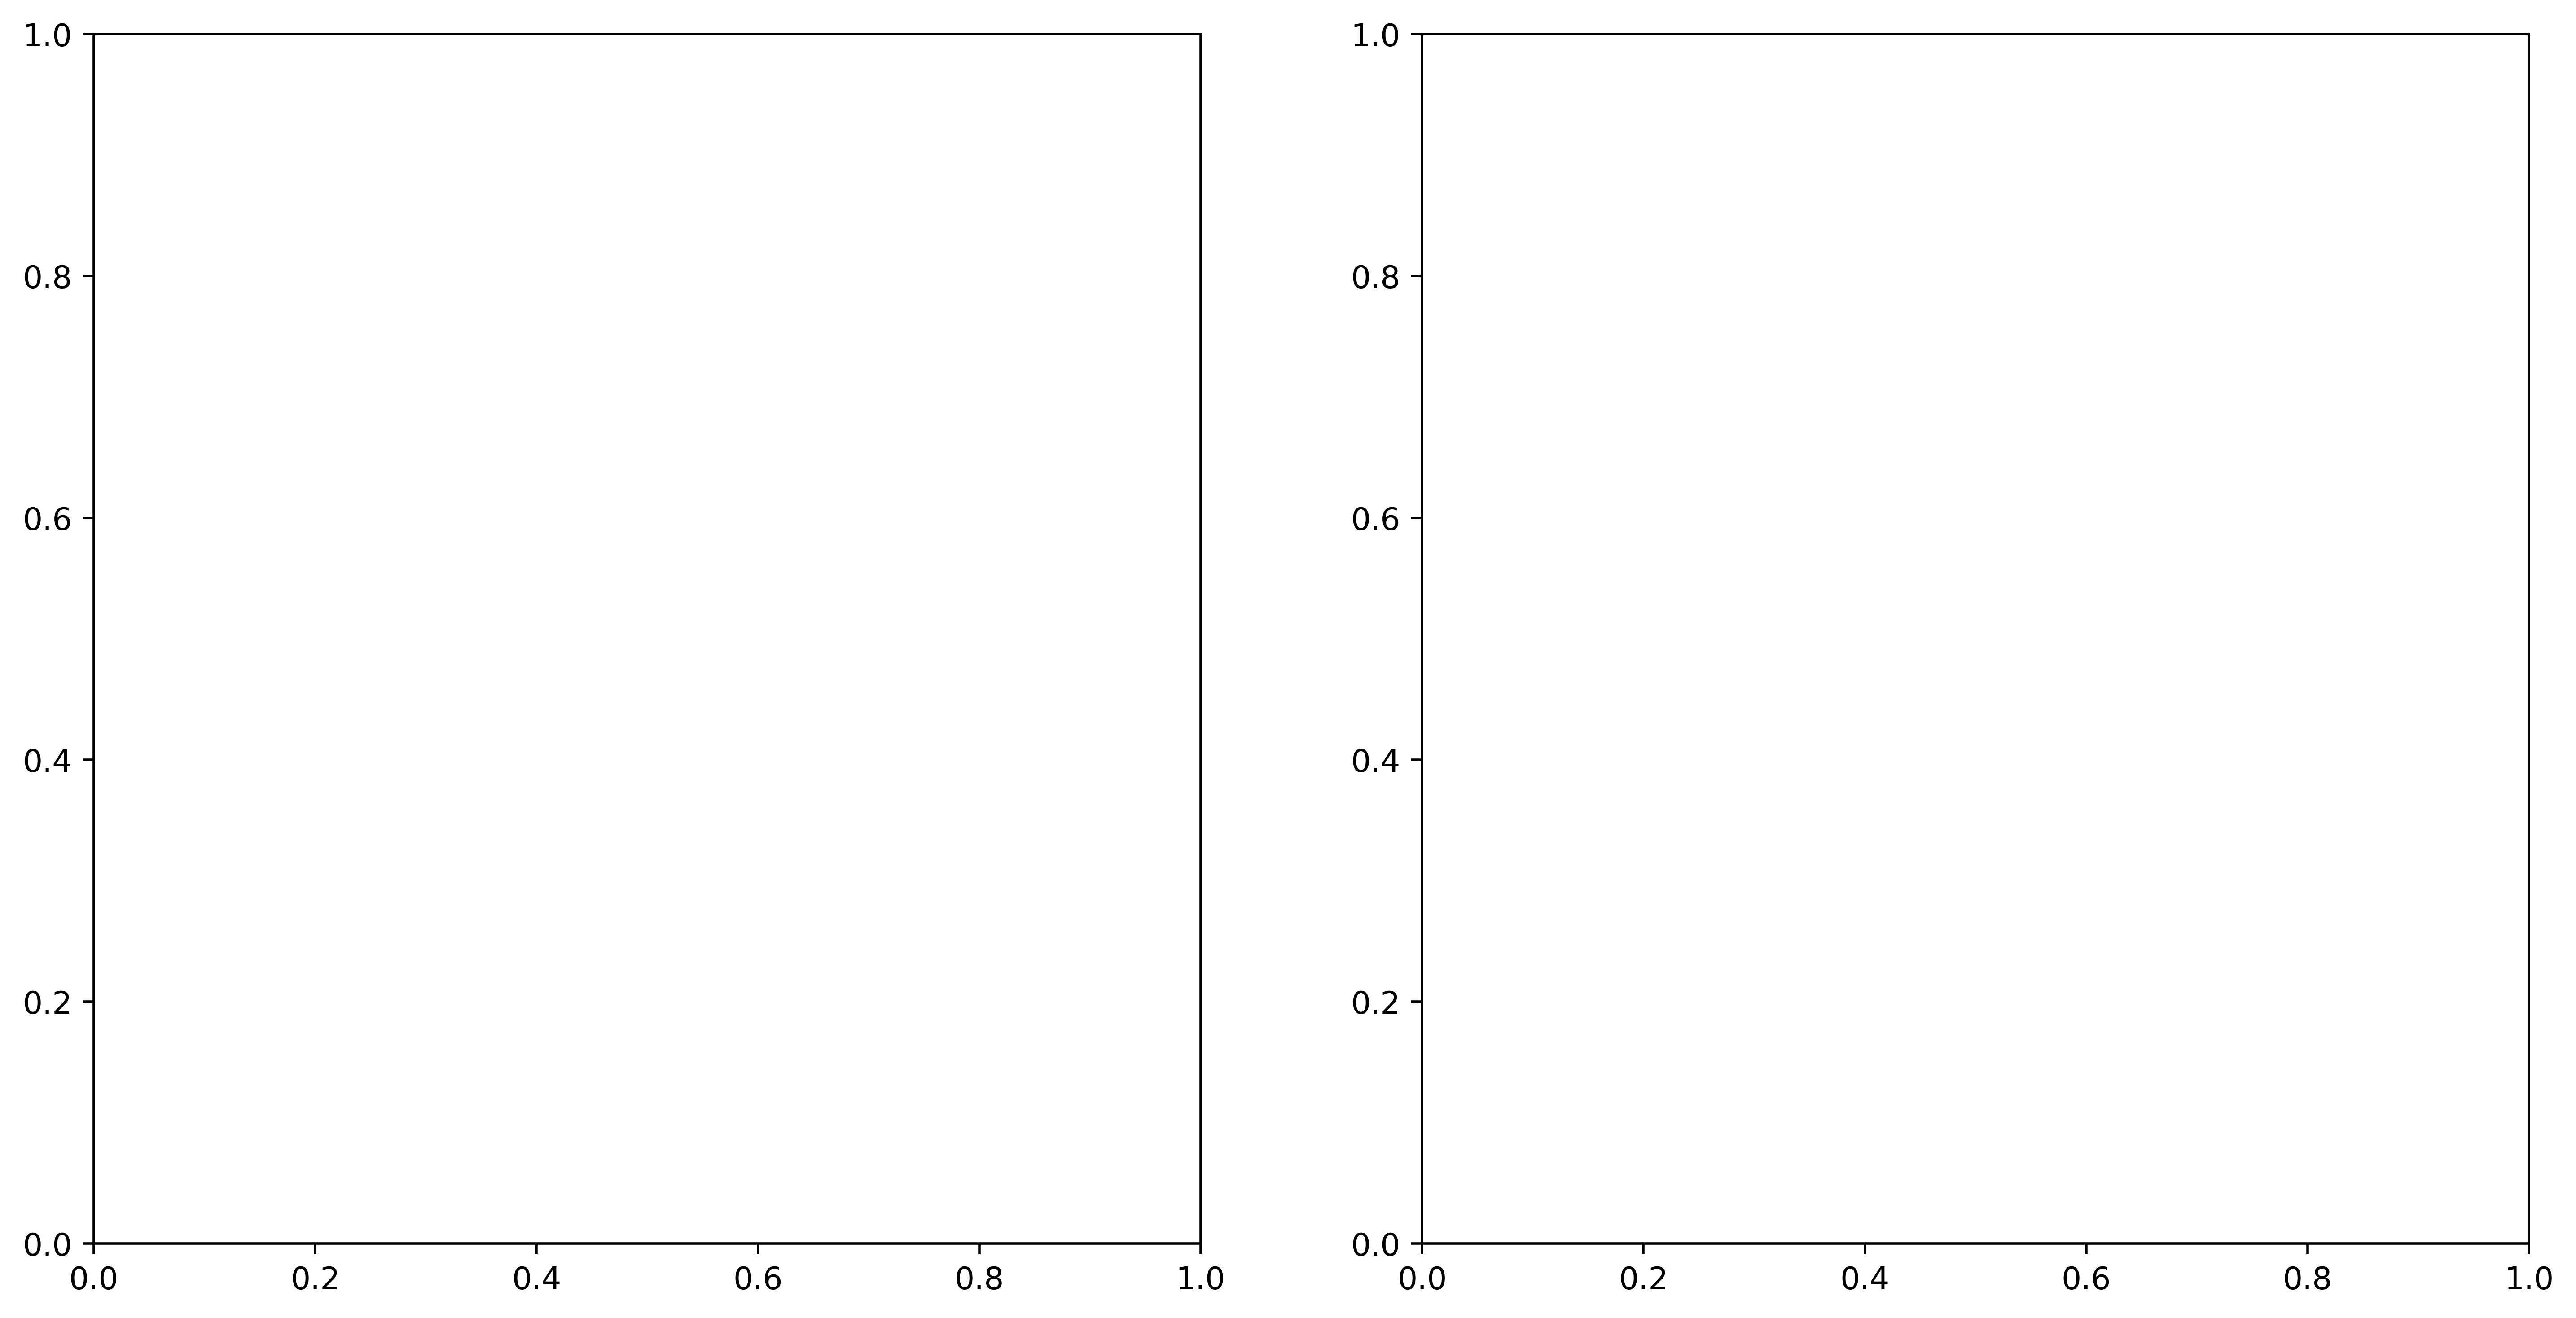

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Supongamos que tu variable de grados de polimerización sigue siendo la misma
N = np.array(grado_polimerizacion) 
N_linea = np.linspace(N.min(), N.max(), 100)

# 1. Definición de la función de ajuste (Ley de potencias)
def ley_potencias(N, A, nu):
    return A * (N**nu)

# Paletas de colores dinámicas para diferenciar las temperaturas
colores_puntos = {0.60: '#1f77b4', 0.65: '#e67e22'}  # Azul y Naranja
colores_lineas = {0.60: '#2980b9', 0.65: '#d35400'}
estilos_linea = {0.60: '-', 0.65: '-'}
marcadores = {0.60: 'o', 0.65: 's'}  # Círculo y Cuadrado

# --- Configuración del Gráfico con Matplotlib ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=False, dpi=500)

# Inicializamos la variable vacía ANTES del bucle para ir acumulando los textos
texto_acumulado_ajustes = ""

# 2. Bucle principal para iterar sobre el diccionario 'resultados'
for T, datos in resultados.items():

    # Extraemos los datos del diccionario convirtiéndolos a arreglos de numpy
    Rg = np.array(datos['Rg'])
    Rg_std = np.array(datos['Rg_std'])
    
    # Realizamos el ajuste no lineal para la temperatura actual (T)
    popt, pcov = curve_fit(ley_potencias, N, Rg, p0=[0.3, 0.5])
    A_opt, nu_opt = popt
    nu_err = np.sqrt(np.diag(pcov))[1]
    
    # Generamos la curva continua de ajuste para esta temperatura
    Rg_ajuste = ley_potencias(N_linea, A_opt, nu_opt)
    Rg_predicho = ley_potencias(N, A_opt, nu_opt)

    # Aplicamos la suma de R2
    residuo = np.sum((Rg - Rg_predicho) ** 2)
    suma_total_cuadrados = np.sum((Rg - np.mean(Rg)) ** 2)
    r_cuadrado = 1 - (residuo / suma_total_cuadrados)

    print(f"Resultados del ajuste para T = {T}:")
    print(f"  -> Exponente (v): {nu_opt:.3f} ± {nu_err:.3f}")
    print(f"  -> Coeficiente R²: {r_cuadrado:.4f}")
    
    # --- SOLUCIÓN AL TEXTO REPETIDO: Acumulamos con "+=" ---
    texto_acumulado_ajustes += f"$T = {T:.2f}: \\nu = {nu_opt:.3f} \\pm {nu_err:.3f}$\n"
    
    # --- Configuración visual por temperatura ---
    color_p = colores_puntos.get(T, '#7f8c8d')
    color_l = colores_lineas.get(T, '#95a5a6')
    estilo = estilos_linea.get(T, '-')
    marcador = marcadores.get(T, '-')

    # --- GRAFICAR EN FIGURA 1 (Escala Lineal) ---
    # Usamos ecolor=color_l junto con el parámetro alpha para atenuarlo de forma independiente al punto
    ax1.errorbar(N, Rg, yerr=Rg_std, fmt=marcador, color=color_p, 
                 ecolor=color_l, elinewidth=1.5, alpha=0.4, 
                 capsize=5, markersize=8)
    # Nota: Para evitar que el 'alpha' afecte al punto si lo pones global, pasamos barras con ecolor
    # Sin embargo, como el método errorbar de matplotlib puede aplicar el alpha global a las barras de error si se comparte,
    # una alternativa ultra-precisa si notas que el punto también se aclara es separar el gráfico:
    
    # Renderizado optimizado para mantener los puntos sólidos y las barras tenues:
    ax1.errorbar(N, Rg, yerr=Rg_std, fmt='none', ecolor=color_l, alpha=0.4, capsize=5)
    ax1.scatter(N, Rg, marker=marcador, color=color_p, s=64, zorder=3)
    
    ax1.plot(N_linea, Rg_ajuste, estilo, color=color_l, linewidth=2,
             label=f'$T^* = {T:.2f}$ ($\\nu={nu_opt:.3f}$)')

    # --- GRAFICAR EN FIGURA 2 (Escala Log-Log) ---
    ax2.errorbar(N, Rg, yerr=Rg_std, fmt='none', ecolor=color_l, alpha=0.4, capsize=5)
    ax2.scatter(N, Rg, marker=marcador, color=color_p, s=64, zorder=3)
    
    ax2.plot(N_linea, Rg_ajuste, estilo, color=color_l, linewidth=2)


# --- Detalles Finales del Gráfico (Fuera del bucle for) ---

# Ajustes de la FIGURA 1
ax1.set_xlabel('Grado de Polimerización ($N$)', fontsize=12)
ax1.set_ylabel('Radio de Giro ($R_g$)', fontsize=12)
ax1.set_title(f'$R_g$ contra la longitud de cadena | $\epsilon$ = {epsilon:.2f}', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xlim(5, 27)
ax1.legend(fontsize=10, loc='upper left', frameon=True)
ax1.set_xticks([8, 16, 24])

# Ajustes de la FIGURA 2
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Grado de Polimerización ($N$)', fontsize=12)
ax2.set_ylabel('Radio de Giro ($R_g$)', fontsize=12)
ax2.set_title('Ajuste en Escala Log-Log', fontsize=13, fontweight='bold')
ax2.grid(True, which="both", linestyle=':', alpha=0.6)
ax2.set_xticks([8, 16, 24])
ax2.set_xticklabels(['8', '16', '24'])

# Añadir la caja de texto unificada en la gráfica

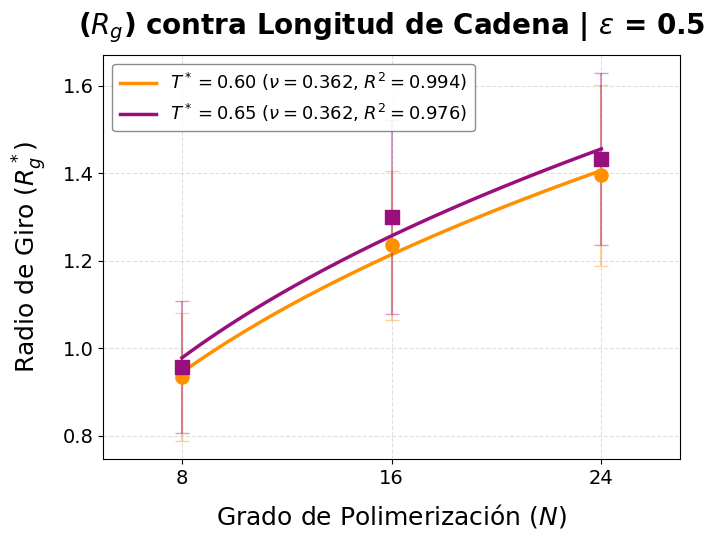

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Asegurar que N contenga tus grados de polimerización
N = np.array(grado_polimerizacion) 
N_linea = np.linspace(N.min(), N.max(), 100)

# 1. Definición de la función de ajuste (Ley de potencias)
def ley_potencias(N, A, nu):
    return A * (N**nu)

# Mapeo de colores solicitados por temperatura (0.60 y 0.65)
colores = {0.60: '#ff9000', 0.65: '#9a0f7e'}
marcadores = {0.60: 'o', 0.65: 's'}

# Configuración del gráfico único para el póster (Compacto y balanceado)
fig, ax = plt.subplots(figsize=(7, 5.5))

texto_acumulado_ajustes = ""

# 2. Bucle principal para iterar sobre el diccionario 'resultados'
for T, datos in resultados.items():
    Rg = np.array(datos['Rg'])
    Rg_std = np.array(datos['Rg_std'])
    
    # Ajuste no lineal
    popt, pcov = curve_fit(ley_potencias, N, Rg, p0=[0.3, 0.5])
    A_opt, nu_opt = popt
    nu_err = np.sqrt(np.diag(pcov))[1]
    
    Rg_ajuste = ley_potencias(N_linea, A_opt, nu_opt)
    Rg_predicho = ley_potencias(N, A_opt, nu_opt)

    # Cálculo de R²
    residuo = np.sum((Rg - Rg_predicho) ** 2)
    suma_total_cuadrados = np.sum((Rg - np.mean(Rg)) ** 2)
    r_cuadrado = 1 - (residuo / suma_total_cuadrados)
    
    texto_acumulado_ajustes += f"$T^* = {T:.2f}: \\nu = {nu_opt:.3f} \\pm {nu_err:.3f}$\n"
    
    # Color y marcador correspondiente a la temperatura
    color_t = colores.get(T, '#7f8c8d')
    marcador = marcadores.get(T, 'o')

    # Graficado de datos (Puntos sólidos y barras de error tenues)
    ax.errorbar(N, Rg, yerr=Rg_std, fmt='none', ecolor=color_t, alpha=0.4, capsize=5)
    ax.scatter(N, Rg, marker=marcador, color=color_t, s=90, zorder=3)
    
    # Curva de ajuste continua (Grosor lw=2.5 ideal para póster)
    ax.plot(N_linea, Rg_ajuste, '-', color=color_t, linewidth=2.5,
            label=f'$T^* = {T:.2f}$ ($\\nu={nu_opt:.3f}$, $R^2={r_cuadrado:.3f}$)')

# --- FORMATO DE TEXTOS GRANDES PARA EL PÓSTER ---

# Título y etiquetas de los ejes
ax.set_title(f'($R_g$) contra Longitud de Cadena | $\epsilon$ = {epsilon:.1f}', fontsize=20, pad=15, fontweight='bold')
ax.set_xlabel('Grado de Polimerización ($N$)', fontsize=18, labelpad=10)
ax.set_ylabel(r'Radio de Giro ($R_g^*$)', fontsize=18, labelpad=10)

# Escalas y números de los ejes (Ticks)
ax.set_xticks([8, 16, 24])
ax.tick_params(axis='both', labelsize=14)
ax.set_xlim(5, 27)

# Rejilla de fondo
ax.grid(True, linestyle='--', alpha=0.4)

# Leyenda grande y con borde gris definido
ax.legend(fontsize=13, loc='upper left', frameon=True, edgecolor='gray', framealpha=0.9)

# Optimización de márgenes
plt.tight_layout()

# Guardar con alta calidad
# plt.savefig('ajuste_exponente_flory.png', dpi=400)
plt.show()